### Imports

In [4]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import random

### Initialization of basics and the TFIM

In [5]:
"""Here we introduce the TFIM Hamiltonian and the true time-dependent parameters for the target Hamiltonian, 
   note that they can be tuned for any other model by just changing the operators and the time-dependence of the parameters """

n_qubits = 6

# Basic Pauli matrices
I_mat = np.array([[1, 0], [0, 1]], dtype=complex)
X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Y_mat = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z_mat = np.array([[1, 0], [0, -1]], dtype=complex)

def mkron(*args):
    """Helper to compute Kronecker product of a list of matrices."""
    res = args[0]
    for op in args[1:]:
        res = np.kron(res, op) 
    return res

def get_op(op, j, N):
    """Places operator 'op' on qubit 'j' in an N-qubit system."""
    ops = [I_mat] * N
    ops[j] = op
    return mkron(*ops)

def state_to_dm(psi_list):
    """Converts a list of single-qubit states into an N-qubit density matrix."""
    psi_full = mkron(*psi_list)
    return np.outer(psi_full, psi_full.conj())

st_z_plus = np.array([1, 0], dtype=complex)
st_z_minus = np.array([0, 1], dtype=complex)
st_y_plus = np.array([1, 1j]) / np.sqrt(2)
st_y_minus = np.array([1, -1j]) / np.sqrt(2)
st_x_plus = np.array([1, 1]) / np.sqrt(2)
st_x_minus = np.array([1, -1]) / np.sqrt(2)

"""Precompute TFIM terms"""
W_X  = [get_op(X_mat, j, n_qubits) for j in range(n_qubits)]
W_YY = [get_op(Y_mat, j, n_qubits) @ get_op(Y_mat, j+1, n_qubits) for j in range(n_qubits - 1)]
Z_ops = [get_op(Z_mat, j, n_qubits) for j in range(n_qubits)]

"""Time-Dependent Target Parameters"""
def true_Omega_X(j, t):
    return 1.0 + 0.5 * np.cos(2 * np.pi * 0.5 * t + j)

def true_J_YY(j, t):
    return 0.5 + 0.2 * t * (j % 2 == 0)

def H_true_func(t):
    H_t = sum([true_Omega_X(j, t) * W_X[j] for j in range(n_qubits)])
    H_t += sum([true_J_YY(j, t) * W_YY[j] for j in range(n_qubits - 1)])
    return H_t

#### Generating the input-data: simulating weak-measurements for time-dependent Hamiltonians using the element-wise implementation 

In [6]:
def simulate_weak_measurements(N, H_func, rho0, T_final, dt, g, N_s):
    num_steps = int(np.round(T_final / dt))
    t_grid = np.linspace(0, T_final, num_steps)
    
    """Precompute Dephasing Matrix M"""
    M1 = np.array([[1.0, np.exp(-g**2/2)],
                   [np.exp(-g**2/2), 1.0]], dtype=complex)
    M = M1
    for _ in range(N - 1): 
        M = np.kron(M, M1)
        
    """Z_ops are already precomputed globally in the initialization section"""
    
    """Simulation Loop"""
    rho = rho0.copy()
    z_ideal = np.zeros((num_steps, N))
    
    for i, t in enumerate(t_grid):
        for q in range(N):
            z_ideal[i, q] = np.real(np.trace(Z_ops[q] @ rho))
            
        """Time-dependent unitary update"""
        H_mid = H_func(t + dt / 2.0)
        U = la.expm(-1j * H_mid * dt)
        U_dag = U.conj().T
        
        rho = U @ rho @ U_dag     
        rho = np.multiply(M, rho) 
        
    """Add Gaussian Noise"""
    noise_std = np.sqrt((g**2 + 1) / (g**2 * N_s))
    z_noisy = z_ideal + np.random.normal(0, noise_std, size=z_ideal.shape)
    
    return t_grid, z_ideal, z_noisy

### Reconstruction algorithm

#### Derivation of the Optimal Time Step ($\Delta t_{opt}$)

To minimize the global reconstruction error in our iterative Hamiltonian learning protocol, we must balance two competing sources of error from the confidence bounds. We separate the core scaling variables from the system-specific physical constants (like the Lipschitz constant $L$ and Euler error $C$) and the chosen statistical failure probability ($\delta$):

1. **Measurement Noise ($E_{noise}$):** Scales as $\frac{1}{\Delta t} \sqrt{\frac{1}{N_s} \log\left(\frac{2Sn}{\delta}\right)}$. Shorter time steps amplify statistical fluctuations from finite-shot measurements.
2. **Integration Bias ($E_{bias}$):** Scales as $\Delta t$. Longer time steps increase the deterministic truncation error from the numerical integration.

Equating the dominant noise and bias terms (and absorbing the unknown physical constants into a proportionality factor):

$$\frac{1}{\Delta t}\sqrt{\frac{2S}{N_s}\log\left(\frac{2Sn}{\delta}\right)} \propto \sqrt{S(\mathcal{D}+1)}\Delta t$$

Solving for $\Delta t$ yields:

$$\Delta t_{opt} \propto \left( \frac{\log\left(\frac{2Sn}{\delta}\right)}{N_s(\mathcal{D}+1)} \right)^{1/4}$$

**The Role of $\delta$ and the Empirical Prefactor:**
Because the statistical confidence parameter $\delta$ is an arbitrary choice, and because bounds like the exact Euler truncation error are generally unknown *a priori*, we cannot compute a strict, universal constant for the time step. 

Instead, this derivation extracts the fundamental scaling law: **the optimal time step scales precisely as $N_s^{-1/4}$**. In our numerical implementation, we capture the unknown physical constants and our chosen confidence level $\delta$ using a single tunable empirical prefactor $\eta$:

$$\Delta t_{opt} = \eta \left( \frac{\log(2Sn)}{N_s(\mathcal{D}+1)} \right)^{1/4}$$

This guarantees that if we scale up our experiment (e.g., taking $10\times$ more shots), the algorithm automatically scales the time step appropriately without needing to re-tune $\eta$.

### Minimal set of states via graph coloring

5320 0.0006578485067635919
Simulating Data...
Precomputing operators...
Reconstructing...


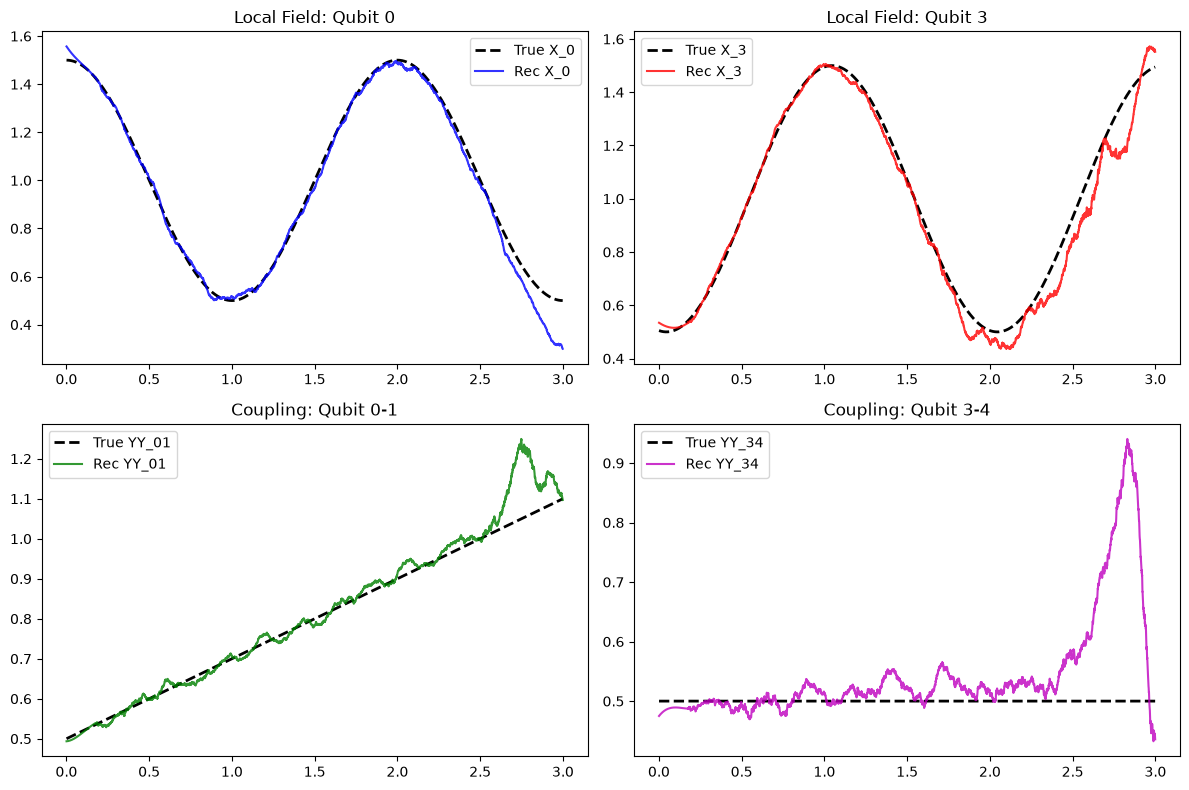

In [ ]:
S_states = 9       
T_target = 3.0       # The actual physics time we want to reconstruct
T_final = 3.5        # The simulation time (includes 0.5s buffer for the filter)
Gamma_d = 0.001
N_shots = 1e9

"The interaction graph degree (max neighbors per qubit)"
D=4  

"Calculate the theoretical base dt"
base_dt = ( (2 * np.log(2 * S_states * n_qubits)) / (N_shots * (D + 1)) )**0.25

# Scale by an empirical prefactor (start around 0.1 - 10 and tune)
eta = 0.1 
dt = eta*base_dt

g = np.sqrt(2 * Gamma_d * dt)       # Weak measurement strength
num_steps = int(np.round(T_final / dt))
times = np.linspace(0, T_final, num_steps, endpoint=False)

print(num_steps, dt)

# ---------------------------------------------------------
"The 9 Optimal Separable States (Physics-Informed 3-Coloring)"
# ---------------------------------------------------------
st_y_plus = np.array([1, 1j]) / np.sqrt(2)
st_y_minus = np.array([1, -1j]) / np.sqrt(2)
st_x_plus = np.array([1, 1]) / np.sqrt(2)
st_x_minus = np.array([1, -1]) / np.sqrt(2)
st_z_plus = np.array([1, 0])
st_z_minus = np.array([0, 1])

initial_rhos = []

# Helper function to tile the optimal local pattern across the graph coloring
def create_optimal_probe(target_color, local_pattern):
    # local_pattern = (Left_Neighbor_State, Target_State, Right_Neighbor_State)
    state_list = []
    for i in range(n_qubits):
        if i % 3 == target_color:
            state_list.append(local_pattern[1])  # Target qubit
        elif i % 3 == (target_color - 1) % 3:
            state_list.append(local_pattern[0])  # Left neighbor
        elif i % 3 == (target_color + 1) % 3:
            state_list.append(local_pattern[2])  # Right neighbor (Reference)
    return state_to_dm(state_list)

p_local_field = (st_x_plus, st_y_plus, st_x_plus)
p_left_couple = (st_y_minus, st_x_plus, st_z_plus)
p_right_couple = (st_z_plus, st_x_plus, st_y_minus)

# Generate the 9 global states (3 target colors * 3 local isolation patterns)
for color in range(3):
    initial_rhos.append(create_optimal_probe(color, p_local_field))
    initial_rhos.append(create_optimal_probe(color, p_left_couple))
    initial_rhos.append(create_optimal_probe(color, p_right_couple))

print("Simulating Data...")
z_data_ideal = np.zeros((S_states, n_qubits, num_steps))
z_data_noisy = np.zeros((S_states, n_qubits, num_steps))
for s in range(S_states):
    _, z_ideal, z_noisy = simulate_weak_measurements(n_qubits, H_true_func, initial_rhos[s], T_final, dt, g, N_shots)
    z_data_ideal[s, :, :] = z_ideal.T  
    z_data_noisy[s, :, :] = z_noisy.T 

# We will store the smoothed derivatives directly to avoid doing (z[t+1]-z[t-1])/2dt
dz_dt_smoothed = np.zeros_like(z_data_noisy)

# Parameters for the filter 
# window_length must be odd. Larger = more smoothing. 
# polyorder is the polynomial degree.
polyorder = 3      

target_time_window = 0.35 
raw_window = int(target_time_window / dt)

# Safety checks to guarantee savgol_filter NEVER crashes:
# 1. Cap it strictly below the size of the array
window_length = min(raw_window, num_steps - 1)

# 2. Force it to be an odd number (required by the filter)
if window_length % 2 == 0:
    window_length += 1

# 3. Edge-case safety: If making it odd pushed it larger than the array, step it back
if window_length > num_steps:
    window_length -= 2

# 4. Must be larger than the polynomial order
if window_length <= polyorder:
    window_length = polyorder + 2
    if window_length % 2 == 0:
        window_length += 1

for s in range(S_states):
    for j in range(n_qubits):
        dz_dt_smoothed[s, j, :] = savgol_filter(
        z_data_noisy[s, j, :], 
        window_length, 
        polyorder, 
        deriv=1,     # <--- Computes analytical derivative
        delta=dt     # <--- Scales it automatically
        )

# ---------------------------------------------------------
"Reconstruction Algorithm "
# ---------------------------------------------------------
def get_neighborhood(j):
    N_j = [('X', j, W_X[j])]
    if j > 0: N_j.append(('YY', j-1, W_YY[j-1]))
    if j < n_qubits - 1: N_j.append(('YY', j, W_YY[j]))
    return N_j

# Calculate the exact step index where our target physics ends
target_num_steps = int(np.round(T_target / dt))

# Initialize arrays using target_num_steps instead of num_steps
theta_X_rec = np.zeros((n_qubits, target_num_steps - 1))
theta_YY_rec = np.zeros((n_qubits - 1, target_num_steps - 1))
rec_rhos = [np.array(rho.copy(), dtype=complex) for rho in initial_rhos]

# Precompute Commutators 
print("Precomputing operators...")
precomputed_comms = {}
for j in range(n_qubits):
    precomputed_comms[j] = []
    for m_idx, (term_type, term_index, W_m) in enumerate(get_neighborhood(j)):
        precomputed_comms[j].append(Z_ops[j] @ W_m - W_m @ Z_ops[j])

# Precompute Euler Dissipator Mask 
ones_mat = np.ones((2**n_qubits, 2**n_qubits), dtype=complex)
euler_diss_mask = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)

for j in range(n_qubits):
    mask_j = Z_ops[j] @ ones_mat @ Z_ops[j]
    euler_diss_mask += (Gamma_d / 2.0) * (mask_j - 1.0)

print("Reconstructing...")
# ONLY reconstruct up to the target time, leaving the buffer zone untouched
for t_idx in range(1, target_num_steps - 1):  
    local_estimates = {'X': {i: [] for i in range(n_qubits)}, 
                       'YY': {i: [] for i in range(n_qubits - 1)}}
    
    for j in range(n_qubits):
        N_j = get_neighborhood(j)
        M_j = np.zeros((S_states, len(N_j)), dtype=float) 
        dSigma_j = np.zeros(S_states)
        
        # RECONSTRUCTION LOOP
        for s in range(S_states):
            # Use the pre-computed smoothed derivative

            # dSigma_j[s] = (z_data_ideal[s, j, t_idx + 1] - z_data_ideal[s, j, t_idx - 1]) / (2 * dt)
            dSigma_j[s] = dz_dt_smoothed[s, j, t_idx] 
            
            for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
                comm = precomputed_comms[j][m_idx]
                trace_val = np.einsum('ij,ji->', comm, rec_rhos[s]) 
                M_j[s, m_idx] = np.real(-1j * trace_val)
                
        # ---------------------------------------------------------
        # STRICT MOORE-PENROSE PSEUDOINVERSE (with Absolute Truncation)
        # ---------------------------------------------------------
        U, S_vals, Vh = np.linalg.svd(M_j, full_matrices=False)
        
        # Absolute noise floor (Tune between 1e-2 and 1e-4 if needed)
        absolute_cutoff = 5e-3 
        
        S_inv = np.zeros_like(S_vals)
        valid_indices = S_vals > absolute_cutoff
        S_inv[valid_indices] = 1.0 / S_vals[valid_indices]
        
        M_j_pinv = Vh.T @ np.diag(S_inv) @ U.T
        theta_j_est = np.real(M_j_pinv @ dSigma_j)
        # ---------------------------------------------------------
        
        for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
            local_estimates[term_type][term_index].append(theta_j_est[m_idx])
            
    # Stitching
    H_rec = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    for j in range(n_qubits):
        theta_X_rec[j, t_idx] = np.mean(local_estimates['X'][j])
        H_rec += theta_X_rec[j, t_idx] * W_X[j]
    for j in range(n_qubits - 1):
        theta_YY_rec[j, t_idx] = np.mean(local_estimates['YY'][j])
        H_rec += theta_YY_rec[j, t_idx] * W_YY[j]
        
    # FAST STATE PROPAGATION
    for s in range(S_states):
        # Coherent part (standard matrix multiplication)
        drho_coherent = -1j * (H_rec @ rec_rhos[s] - rec_rhos[s] @ H_rec)
        
        # Dissipative part (fast element-wise multiplication using the precomputed mask)
        drho_dissipative = euler_diss_mask * rec_rhos[s] 
        
        # Explicit Euler Update
        rec_rhos[s] += (drho_coherent + drho_dissipative) * dt

        # FIX 1: Enforce Hermiticity
        rec_rhos[s] = 0.5 * (rec_rhos[s] + rec_rhos[s].conj().T)
        # FIX 2: Enforce Trace = 1
        rec_rhos[s] = rec_rhos[s] / np.trace(rec_rhos[s])

# ---------------------------------------------------------
"Plotting the Results"
# ---------------------------------------------------------
# Slice the plot times to exactly match the target physics window
plot_times = times[1:target_num_steps-1] 
plot_X_rec = theta_X_rec[:, 1:]
plot_YY_rec = theta_YY_rec[:, 1:]

theta_X_opt = theta_X_rec.copy()
theta_YY_opt = theta_YY_rec.copy()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].plot(plot_times, [true_Omega_X(0, t) for t in plot_times], 'k--', lw=2, label='True X_0')
axs[0,0].plot(plot_times, plot_X_rec[0, :], 'b-', alpha=0.8, lw=1.5, label='Rec X_0')
axs[0,0].set_title('Local Field: Qubit 0')
axs[0,0].legend()

axs[0,1].plot(plot_times, [true_Omega_X(3, t) for t in plot_times], 'k--', lw=2, label='True X_3')
axs[0,1].plot(plot_times, plot_X_rec[3, :], 'r-', alpha=0.8, lw=1.5, label='Rec X_3')
axs[0,1].set_title('Local Field: Qubit 3')
axs[0,1].legend()

axs[1,0].plot(plot_times, [true_J_YY(0, t) for t in plot_times], 'k--', lw=2, label='True YY_01')
axs[1,0].plot(plot_times, plot_YY_rec[0, :], 'g-', alpha=0.8, lw=1.5, label='Rec YY_01')
axs[1,0].set_title('Coupling: Qubit 0-1')
axs[1,0].legend()

axs[1,1].plot(plot_times, [true_J_YY(3, t) for t in plot_times], 'k--', lw=2, label='True YY_34')
axs[1,1].plot(plot_times, plot_YY_rec[3, :], 'm-', alpha=0.8, lw=1.5, label='Rec YY_34')
axs[1,1].set_title('Coupling: Qubit 3-4')
axs[1,1].legend()

plt.tight_layout()
plt.show()

### Overcomplete set of states

Smoothing noisy data to compute stable derivatives...
4986 0.0007019141630171179
Simulating Data...
Precomputing operators...
Reconstructing...


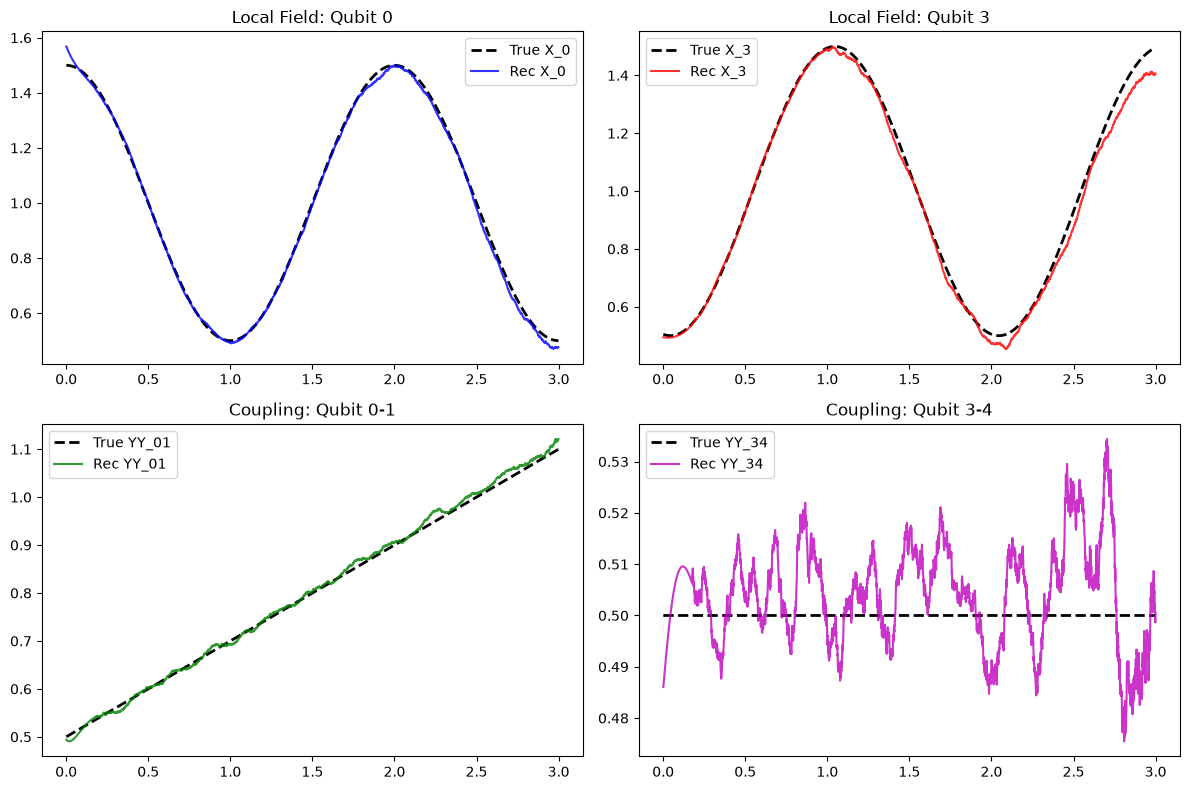

In [ ]:
print("Smoothing noisy data to compute stable derivatives...")

S_states = 36       
T_target = 3.0       # The actual physics time we want to reconstruct
T_final = 3.5        # The simulation time (includes 0.5s buffer for the filter)
Gamma_d = 0.001
N_shots = 1e9 

"The interaction graph degree (max neighbors per qubit)"
D=4  

"Calculate the theoretical base dt"
base_dt = ( (2 * np.log(2 * S_states * n_qubits)) / (N_shots * (D + 1)) )**0.25

eta = 0.1 
dt = eta * base_dt

g = np.sqrt(2 * Gamma_d * dt)       # Weak measurement strength
num_steps = int(np.round(T_final / dt))
times = np.linspace(0, T_final, num_steps, endpoint=False)

print(num_steps, dt)

# ---------------------------------------------------------
"Robust Overcomplete Pauli States"
# ---------------------------------------------------------

pauli_states = [st_x_plus, st_x_minus, st_y_plus, st_y_minus, st_z_plus, st_z_minus]

initial_rhos = []
np.random.seed(42)
random.seed(42)

for _ in range(S_states):
    # Pick a random Pauli eigenstate for each qubit independently
    state_list = [random.choice(pauli_states) for _ in range(n_qubits)]
    initial_rhos.append(state_to_dm(state_list))
# ---------------------------------------------------------

print("Simulating Data...")
z_data_ideal = np.zeros((S_states, n_qubits, num_steps))
z_data_noisy = np.zeros((S_states, n_qubits, num_steps))
for s in range(S_states):
    _, z_ideal, z_noisy = simulate_weak_measurements(n_qubits, H_true_func, initial_rhos[s], T_final, dt, g, N_shots)
    z_data_ideal[s, :, :] = z_ideal.T  
    z_data_noisy[s, :, :] = z_noisy.T 


dz_dt_smoothed = np.zeros_like(z_data_noisy)

polyorder = 3      

target_time_window = 0.35 
raw_window = int(target_time_window / dt)
window_length = min(raw_window, num_steps - 1)

if window_length % 2 == 0:
    window_length += 1

if window_length > num_steps:
    window_length -= 2

if window_length <= polyorder:
    window_length = polyorder + 2
    if window_length % 2 == 0:
        window_length += 1

for s in range(S_states):
    for j in range(n_qubits):
        dz_dt_smoothed[s, j, :] = savgol_filter(
        z_data_noisy[s, j, :], 
        window_length, 
        polyorder, 
        deriv=1,     # <--- Computes analytical derivative
        delta=dt     # <--- Scales it automatically
        )

# ---------------------------------------------------------
"Reconstruction Algorithm"
# ---------------------------------------------------------
def get_neighborhood(j):
    N_j = [('X', j, W_X[j])]
    if j > 0: N_j.append(('YY', j-1, W_YY[j-1]))
    if j < n_qubits - 1: N_j.append(('YY', j, W_YY[j]))
    return N_j

target_num_steps = int(np.round(T_target / dt))

theta_X_rec = np.zeros((n_qubits, target_num_steps - 1))
theta_YY_rec = np.zeros((n_qubits - 1, target_num_steps - 1))
rec_rhos = [np.array(rho.copy(), dtype=complex) for rho in initial_rhos]

print("Precomputing operators...")
precomputed_comms = {}
for j in range(n_qubits):
    precomputed_comms[j] = []
    for m_idx, (term_type, term_index, W_m) in enumerate(get_neighborhood(j)):
        precomputed_comms[j].append(Z_ops[j] @ W_m - W_m @ Z_ops[j])

ones_mat = np.ones((2**n_qubits, 2**n_qubits), dtype=complex)
euler_diss_mask = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)

for j in range(n_qubits):
    mask_j = Z_ops[j] @ ones_mat @ Z_ops[j]
    euler_diss_mask += (Gamma_d / 2.0) * (mask_j - 1.0)

print("Reconstructing...")
# ONLY reconstruct up to the target time, leaving the buffer zone untouched
for t_idx in range(1, target_num_steps - 1):  
    local_estimates = {'X': {i: [] for i in range(n_qubits)}, 
                       'YY': {i: [] for i in range(n_qubits - 1)}}
    
    for j in range(n_qubits):
        N_j = get_neighborhood(j)
        M_j = np.zeros((S_states, len(N_j)), dtype=float) 
        dSigma_j = np.zeros(S_states)
        
        # RECONSTRUCTION LOOP
        for s in range(S_states):
            # NO MORE FINITE DIFFERENCE HERE!
            # Use the pre-computed smoothed derivative
            dSigma_j[s] = dz_dt_smoothed[s, j, t_idx] 
            
            for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
                comm = precomputed_comms[j][m_idx]
                trace_val = np.einsum('ij,ji->', comm, rec_rhos[s]) 
                M_j[s, m_idx] = np.real(-1j * trace_val)
                
        # ---------------------------------------------------------
        # STRICT MOORE-PENROSE PSEUDOINVERSE (with Absolute Truncation)
        # ---------------------------------------------------------
        U, S_vals, Vh = np.linalg.svd(M_j, full_matrices=False)
        
        # Absolute noise floor (Tune between 1e-2 and 1e-4 if needed)
        absolute_cutoff = 5e-3 
        
        S_inv = np.zeros_like(S_vals)
        valid_indices = S_vals > absolute_cutoff
        S_inv[valid_indices] = 1.0 / S_vals[valid_indices]
        
        M_j_pinv = Vh.T @ np.diag(S_inv) @ U.T
        theta_j_est = np.real(M_j_pinv @ dSigma_j)
        # ---------------------------------------------------------
        
        for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
            local_estimates[term_type][term_index].append(theta_j_est[m_idx])
            
    # Stitching
    H_rec = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    for j in range(n_qubits):
        theta_X_rec[j, t_idx] = np.mean(local_estimates['X'][j])
        H_rec += theta_X_rec[j, t_idx] * W_X[j]
    for j in range(n_qubits - 1):
        theta_YY_rec[j, t_idx] = np.mean(local_estimates['YY'][j])
        H_rec += theta_YY_rec[j, t_idx] * W_YY[j]
        
    # FAST STATE PROPAGATION
    for s in range(S_states):
        # Coherent part (standard matrix multiplication)
        drho_coherent = -1j * (H_rec @ rec_rhos[s] - rec_rhos[s] @ H_rec)
        
        # Dissipative part (fast element-wise multiplication using the precomputed mask)
        drho_dissipative = euler_diss_mask * rec_rhos[s] 
        
        # Explicit Euler Update
        rec_rhos[s] += (drho_coherent + drho_dissipative) * dt

        # FIX 1: Enforce Hermiticity
        rec_rhos[s] = 0.5 * (rec_rhos[s] + rec_rhos[s].conj().T)
        # FIX 2: Enforce Trace = 1
        rec_rhos[s] = rec_rhos[s] / np.trace(rec_rhos[s])


# ---------------------------------------------------------
"Plotting the results"
# ---------------------------------------------------------

plot_times = times[1:target_num_steps-1] 
plot_X_rec = theta_X_rec[:, 1:]
plot_YY_rec = theta_YY_rec[:, 1:]

theta_X_over = theta_X_rec.copy()
theta_YY_over = theta_YY_rec.copy()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0,0].plot(plot_times, [true_Omega_X(0, t) for t in plot_times], 'k--', lw=2, label='True X_0')
axs[0,0].plot(plot_times, plot_X_rec[0, :], 'b-', alpha=0.8, lw=1.5, label='Rec X_0')
axs[0,0].set_title('Local Field: Qubit 0')
axs[0,0].legend()

axs[0,1].plot(plot_times, [true_Omega_X(3, t) for t in plot_times], 'k--', lw=2, label='True X_3')
axs[0,1].plot(plot_times, plot_X_rec[3, :], 'r-', alpha=0.8, lw=1.5, label='Rec X_3')
axs[0,1].set_title('Local Field: Qubit 3')
axs[0,1].legend()

axs[1,0].plot(plot_times, [true_J_YY(0, t) for t in plot_times], 'k--', lw=2, label='True YY_01')
axs[1,0].plot(plot_times, plot_YY_rec[0, :], 'g-', alpha=0.8, lw=1.5, label='Rec YY_01')
axs[1,0].set_title('Coupling: Qubit 0-1')
axs[1,0].legend()

axs[1,1].plot(plot_times, [true_J_YY(3, t) for t in plot_times], 'k--', lw=2, label='True YY_34')
axs[1,1].plot(plot_times, plot_YY_rec[3, :], 'm-', alpha=0.8, lw=1.5, label='Rec YY_34')
axs[1,1].set_title('Coupling: Qubit 3-4')
axs[1,1].legend()

plt.tight_layout()
plt.show()

Generating Z(t) filter diagnostic plots...


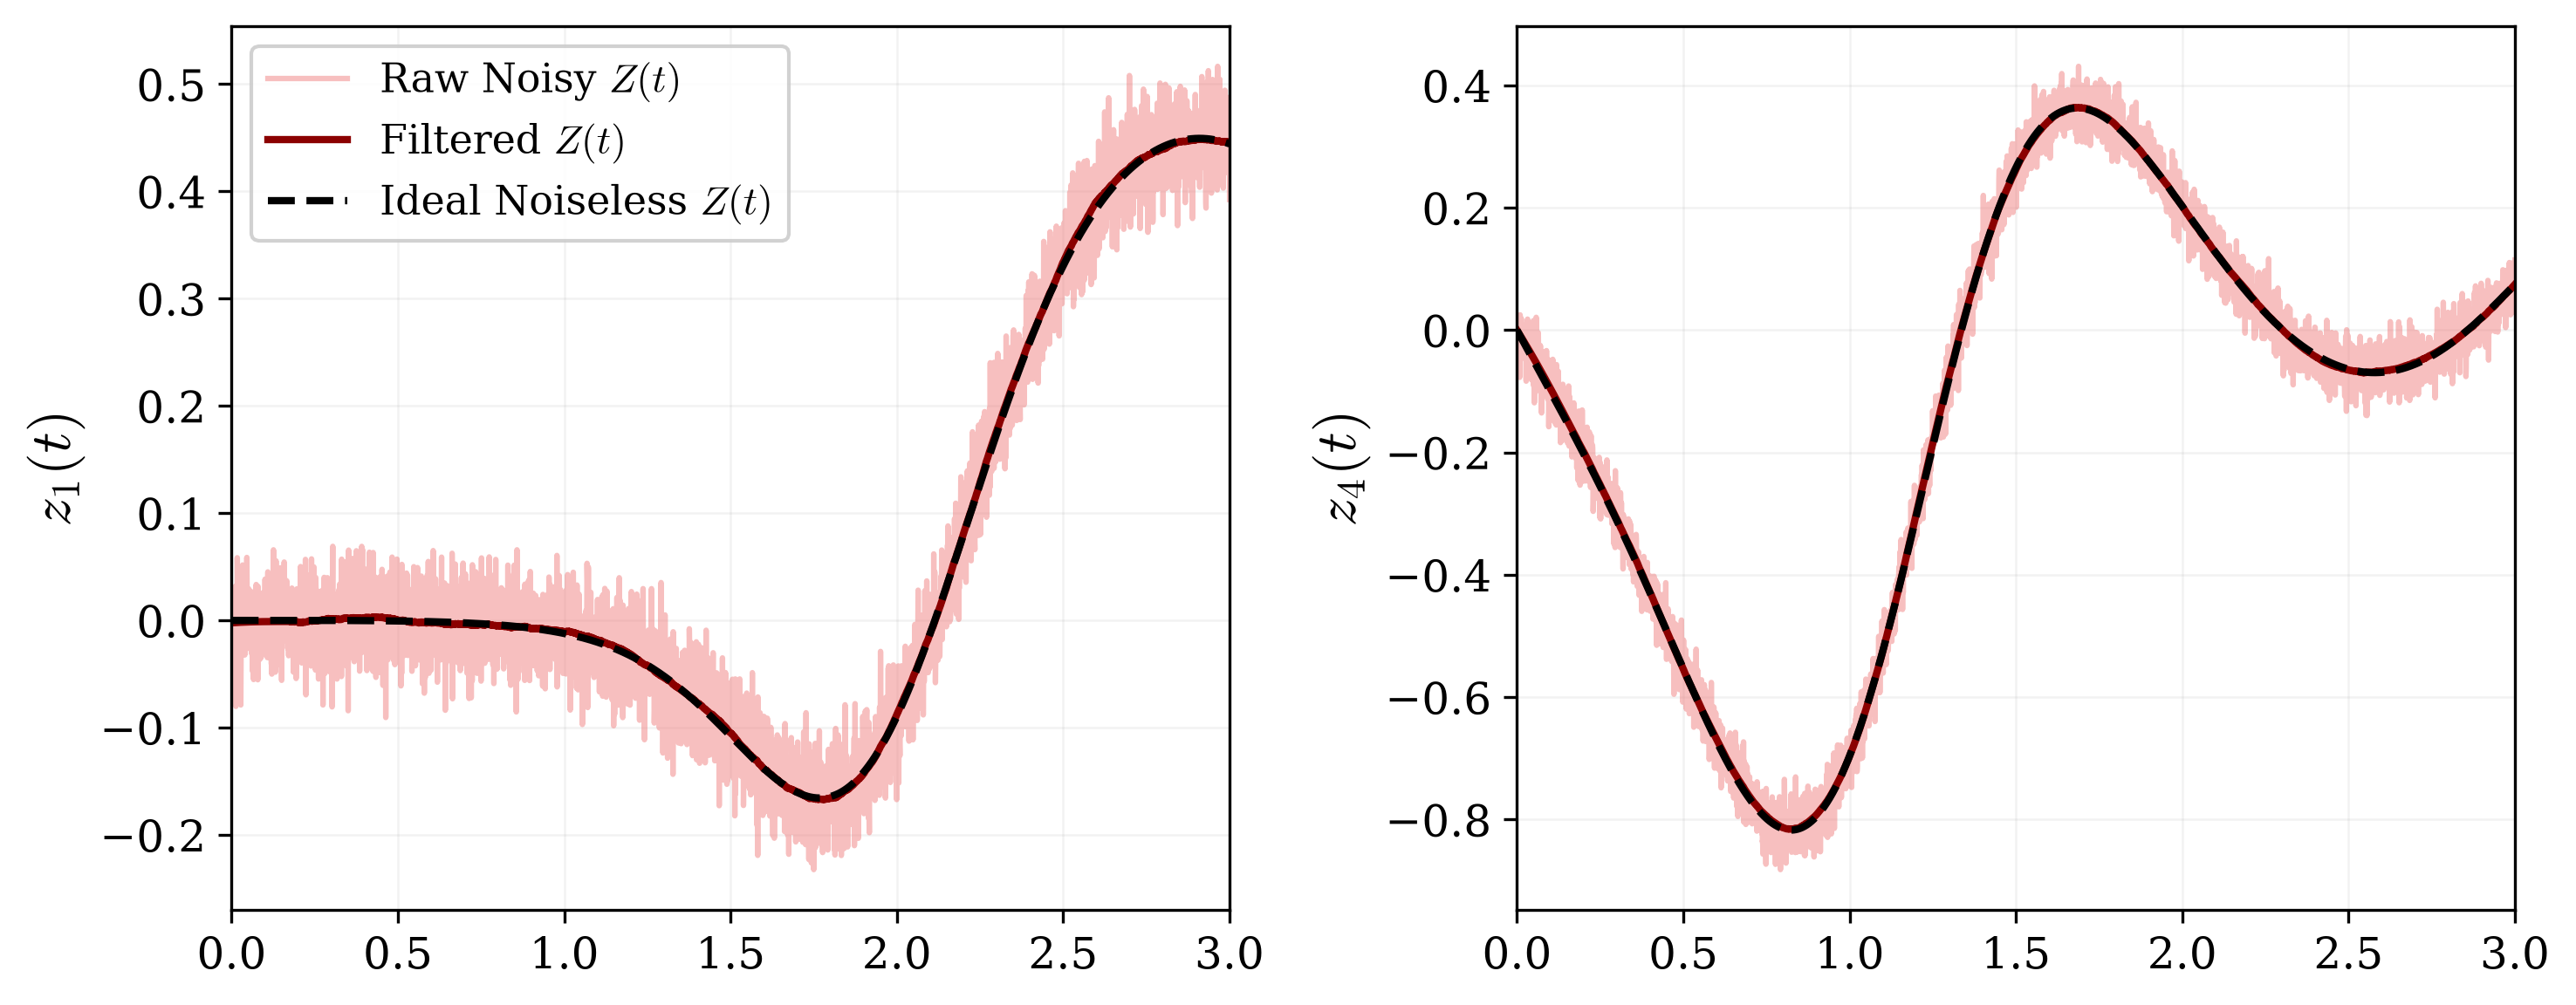

In [ ]:
plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "cm",             
    "font.family": "serif",               
    "axes.labelsize": 16,
    "axes.titlesize": 15,
    "font.size": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
# ---------------------------------------------------------

print("Generating Z(t) filter diagnostic plots...")

# Pick a random state from your generated set
s_plot = np.random.randint(0, S_states)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharex=True, dpi=300)

qubit_indices = [0, 3]
y_labels = [r'$z_1(t)$', r'$z_4(t)$']
x_labels = [r'$t$ (s)', r'$t$ (s)']

for i, j in enumerate(qubit_indices):
    ax = axs[i]
    
    raw_z = z_data_noisy[s_plot, j, :]
    ideal_z = z_data_ideal[s_plot, j, :]
    
    smoothed_z = savgol_filter(raw_z, window_length, polyorder)
    
    ax.plot(times, raw_z, color='lightcoral', alpha=0.5, label='Raw Noisy $Z(t)$')
    
    ax.plot(times, smoothed_z, color='darkred', lw=2, label='Filtered $Z(t)$')
    
    ax.plot(times, ideal_z, color='black', linestyle='--', lw=2, label='Ideal Noiseless $Z(t)$')
    
    # Formatting
    ax.set_ylabel(y_labels[i])
    
    # Deliberately leaving the x-axis label empty as requested
    ax.set_xlabel('') 
    
    ax.set_xlim(0, 3.0)
    
    ax.grid(True, which='major', alpha=0.16, linewidth=0.6)
    ax.grid(False, which='minor')
    
    if i == 0:
        ax.legend(loc='best', framealpha=0.9, frameon=True)

plt.tight_layout()
plt.savefig('Z_t_Filter_Diagnostics.pdf', bbox_inches='tight')
plt.savefig('Z_t_Filter_Diagnostics.png', dpi=600, bbox_inches='tight')
plt.show()

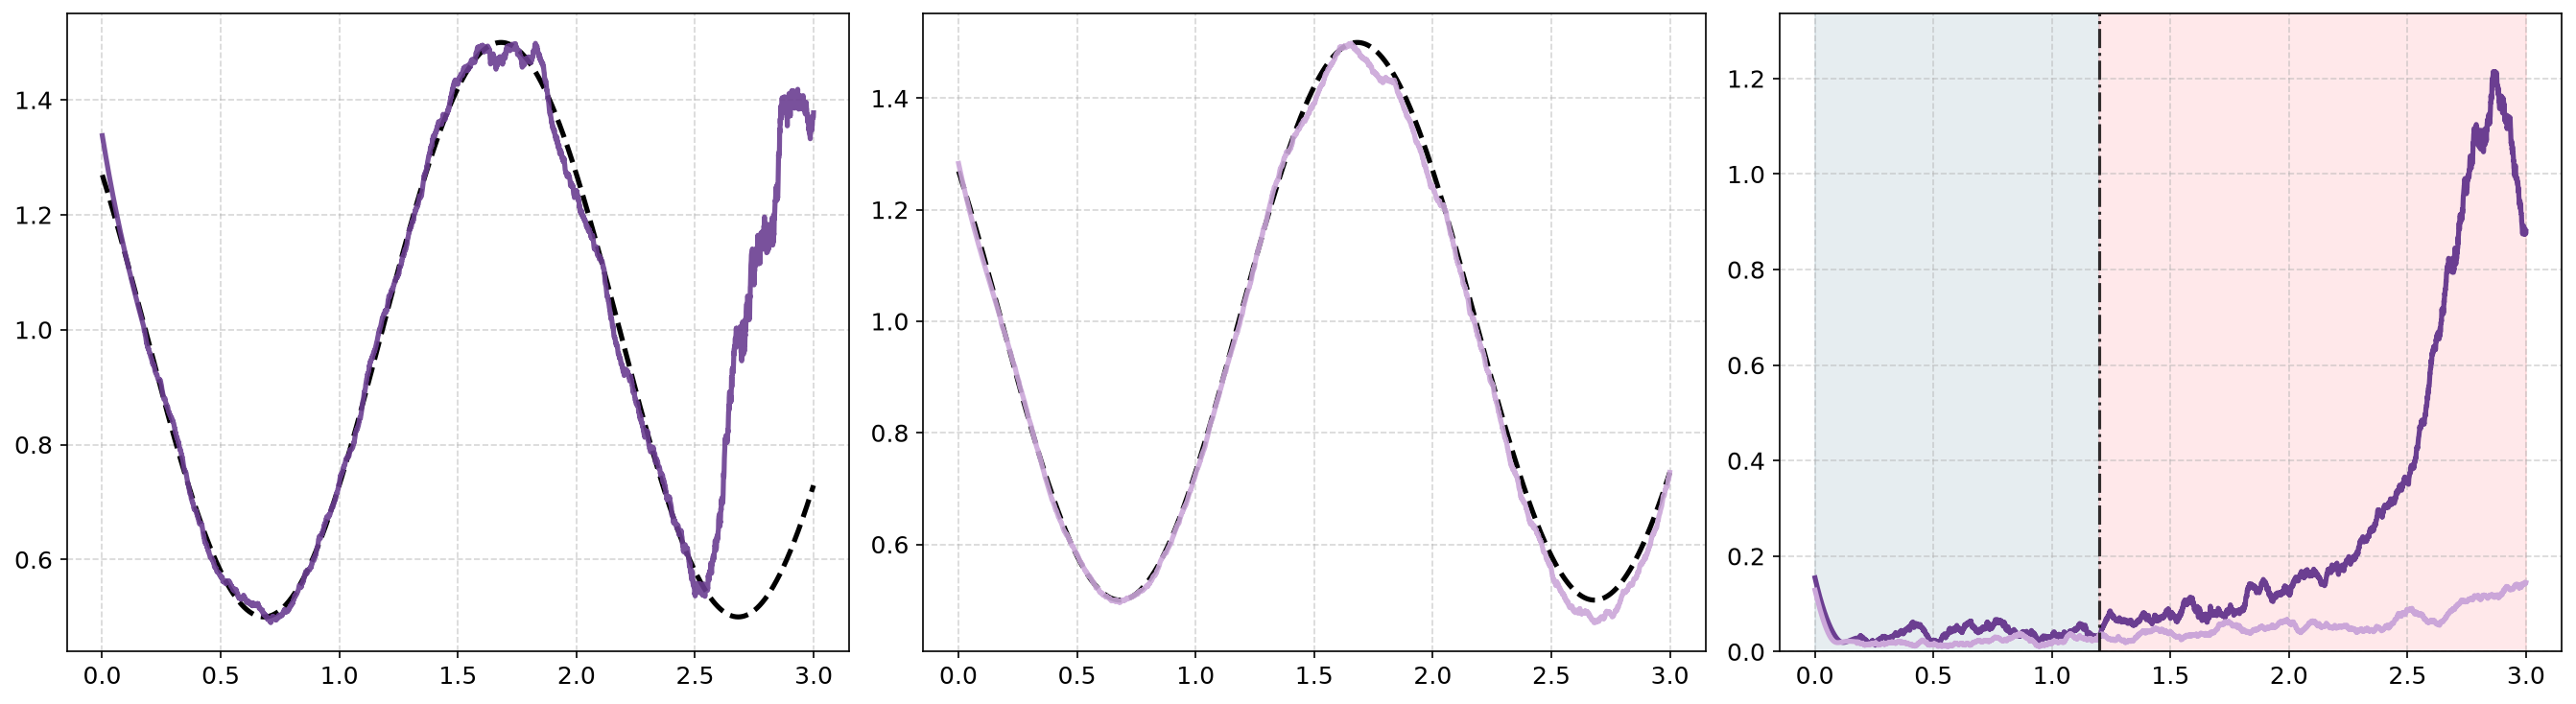

In [ ]:
# ---------------------------------------------------------
# Helper: Calculate Global L2 Error
# ---------------------------------------------------------
def calculate_global_error(rec_X, rec_YY, times_array):
    """
    Computes the L2 norm of the difference between the reconstructed 
    coefficients and the true Hamiltonian coefficients at each time step.
    """
    errors = np.zeros(len(times_array))
    
    for t_idx, t in enumerate(times_array):
        sq_error_sum = 0.0
        
        # Add squared errors for all local X fields
        for j in range(n_qubits):
            sq_error_sum += (rec_X[j, t_idx] - true_Omega_X(j, t))**2
            
        # Add squared errors for all YY couplings
        for j in range(n_qubits - 1):
            sq_error_sum += (rec_YY[j, t_idx] - true_J_YY(j, t))**2
            
        errors[t_idx] = np.sqrt(sq_error_sum)
        
    return errors


t_final = 3.0 

times_opt = np.linspace(0, t_final, theta_X_opt.shape[1])
times_over = np.linspace(0, t_final, theta_X_over.shape[1])

rec_X_opt = theta_X_opt[:, 1:-1]
rec_YY_opt = theta_YY_opt[:, 1:-1]
plot_times_opt = times_opt[1:-1]

rec_X_over = theta_X_over[:, 1:-1]
rec_YY_over = theta_YY_over[:, 1:-1]
plot_times_over = times_over[1:-1]

error_optimal = calculate_global_error(rec_X_opt, rec_YY_opt, plot_times_opt)
error_overcomplete = calculate_global_error(rec_X_over, rec_YY_over, plot_times_over)


color_opt = '#6b3e91'      # Deep Purple for Optimal (S=9)
color_over = '#cba6d9'     # Pastel Lilac for Overcomplete (S=36)
true_color = 'black'

shade_stable = '#AEC6CF'   # Soft Pastel Blue (Matching/Stable)
shade_drift = '#FFB3BA'    # Soft Pastel Red (Discrepancy/Drift)

target_qubit = 1 
fig, axs = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# --- Panel (a): Optimal Set ---
axs[0].plot(plot_times_opt, [true_Omega_X(target_qubit, t) for t in plot_times_opt], 
            color=true_color, linestyle='--', lw=2.5)
axs[0].plot(plot_times_opt, rec_X_opt[target_qubit, :], 
            color=color_opt, alpha=0.9, lw=2.5)

# --- Panel (b): Overcomplete Set ---
axs[1].plot(plot_times_over, [true_Omega_X(target_qubit, t) for t in plot_times_over], 
            color=true_color, linestyle='--', lw=2.5)
axs[1].plot(plot_times_over, rec_X_over[target_qubit, :], 
            color=color_over, alpha=0.9, lw=2.5)

# --- Panel (c): Global Error ---
axs[2].plot(plot_times_opt, error_optimal, color=color_opt, lw=2.5)
axs[2].plot(plot_times_over, error_overcomplete, color=color_over, lw=2.5)

divergence_time = 1.2  
axs[2].axvline(x=divergence_time, color='black', linestyle='-.', lw=1.5, alpha=0.8)

# Shaded regions using the intuitive presentation colors
axs[2].axvspan(0, divergence_time, color=shade_stable, alpha=0.3)
axs[2].axvspan(divergence_time, t_final, color=shade_drift, alpha=0.3)

# Dynamic Y-Axis Ceiling
safe_y_max = max(np.max(error_optimal), np.max(error_overcomplete)) * 1.1
axs[2].set_ylim(0, safe_y_max)

for ax in axs:
    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # We keep the tick marks so you have a scale reference, 
    # but you will drop your own text boxes over the axes in PowerPoint.
    ax.tick_params(axis='both', which='major', labelsize=12)

plt.savefig("probe_comparison.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

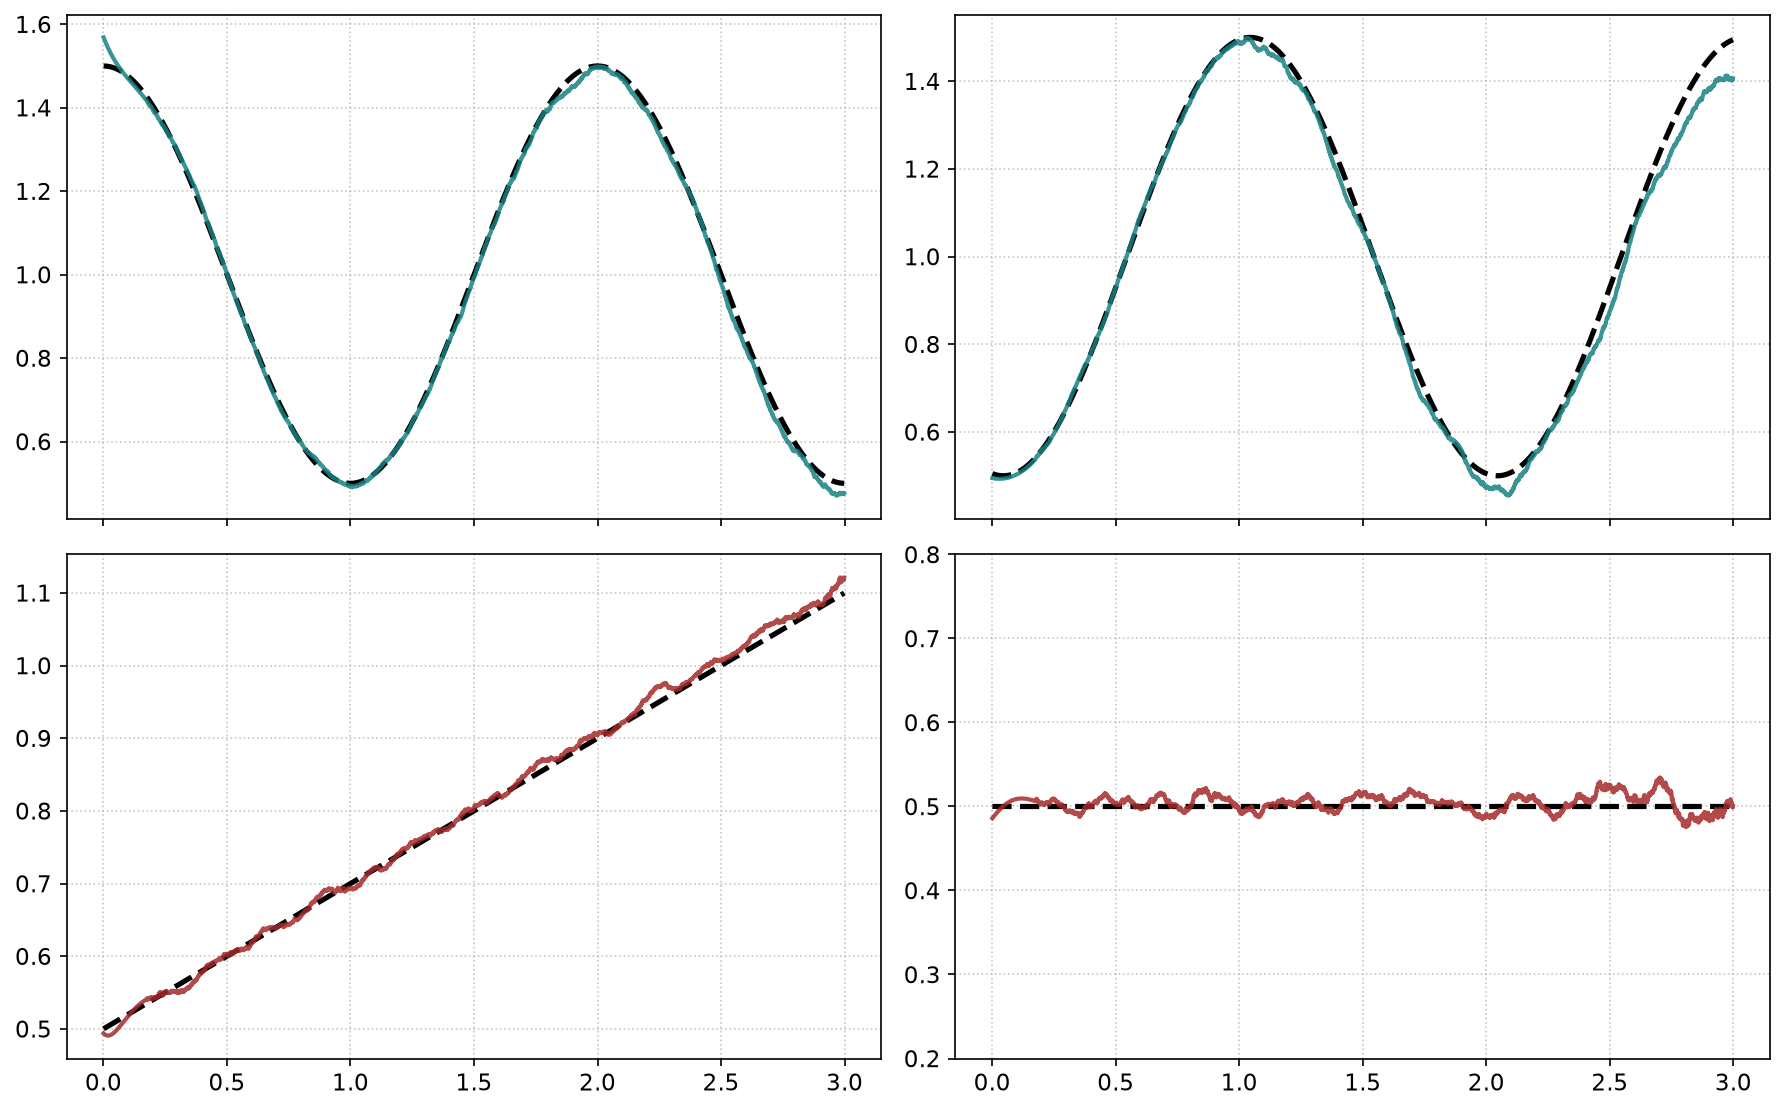

In [ ]:

color_local = '#178082'     # Teal/Blue for Local Fields
color_coupling = '#A52A2A'  # Brick/Red for Couplings
true_color = 'black'

plot_X = theta_X_over[:, 1:]
plot_YY = theta_YY_over[:, 1:]


actual_len = plot_X.shape[1]
t_plot_over = np.arange(1, actual_len + 1) * dt


fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, dpi=150)

edge_q = 0         # Qubit 0 (Edge)
bulk_q = 3         # Qubit 3 (Bulk)
edge_couple = 0    # Coupling 0-1 (Edge)
bulk_couple = 3    # Coupling 3-4 (Bulk)

# --- Panel (a): Edge X Field ---
axs[0, 0].plot(t_plot_over, [true_Omega_X(edge_q, t) for t in t_plot_over], 
               color=true_color, linestyle='--', lw=2.5, label=r'True $\Omega_{X,0}(t)$')
axs[0, 0].plot(t_plot_over, plot_X[edge_q, :], 
               color=color_local, alpha=0.85, lw=2, label='Reconstruction')
#axs[0, 0].set_title(r'(a) Boundary Field (Qubit 0)', fontsize=14)
#axs[0, 0].set_ylabel(r'Local Field $\Omega_X$', fontsize=13)

# --- Panel (b): Bulk X Field ---
axs[0, 1].plot(t_plot_over, [true_Omega_X(bulk_q, t) for t in t_plot_over], 
               color=true_color, linestyle='--', lw=2.5, label=r'True $\Omega_{X,3}(t)$')
axs[0, 1].plot(t_plot_over, plot_X[bulk_q, :], 
               color=color_local, alpha=0.85, lw=2, label='Reconstruction')
#axs[0, 1].set_title(r'(b) Bulk Field (Qubit 3)', fontsize=14)

# --- Panel (c): Edge YY Coupling ---
axs[1, 0].plot(t_plot_over, [true_J_YY(edge_couple, t) for t in t_plot_over], 
               color=true_color, linestyle='--', lw=2.5, label=r'True $J_{YY,01}(t)$')
axs[1, 0].plot(t_plot_over, plot_YY[edge_couple, :], 
               color=color_coupling, alpha=0.85, lw=2, label='Reconstruction')
#axs[1, 0].set_title(r'(c) Boundary Coupling (Qubits 0-1)', fontsize=14)
#axs[1, 0].set_xlabel('Time (t)', fontsize=13)
#axs[1, 0].set_ylabel(r'Coupling $J_{YY}$', fontsize=13)

# --- Panel (d): Bulk YY Coupling ---
axs[1, 1].plot(t_plot_over, [true_J_YY(bulk_couple, t) for t in t_plot_over], 
               color=true_color, linestyle='--', lw=2.5, label=r'True $J_{YY,34}(t)$')
axs[1, 1].plot(t_plot_over, plot_YY[bulk_couple, :], 
               color=color_coupling, alpha=0.85, lw=2, label='Reconstruction')
#axs[1, 1].set_title(r'(d) Bulk Coupling (Qubits 3-4)', fontsize=14)
#axs[1, 1].set_xlabel('Time (t)', fontsize=13)
# --- NEW: Manually set y-axis limits to match the visual scale of Panel (c) ---
axs[1, 1].set_ylim(0.2, 0.8)

# ---------------------------------------------------------
# Global Formatting
# ---------------------------------------------------------
for ax in axs.flat:
     ax.grid(True, linestyle=':', alpha=0.7)
#     ax.legend(loc='best', fontsize=11, framealpha=0.9)
     ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
# fig.suptitle(r'Hamiltonian Coefficient Reconstruction ($n=6$, Overcomplete Set)', fontsize=16, weight='bold')
plt.savefig("reconstruction_n6.pdf", bbox_inches="tight")

plt.show()

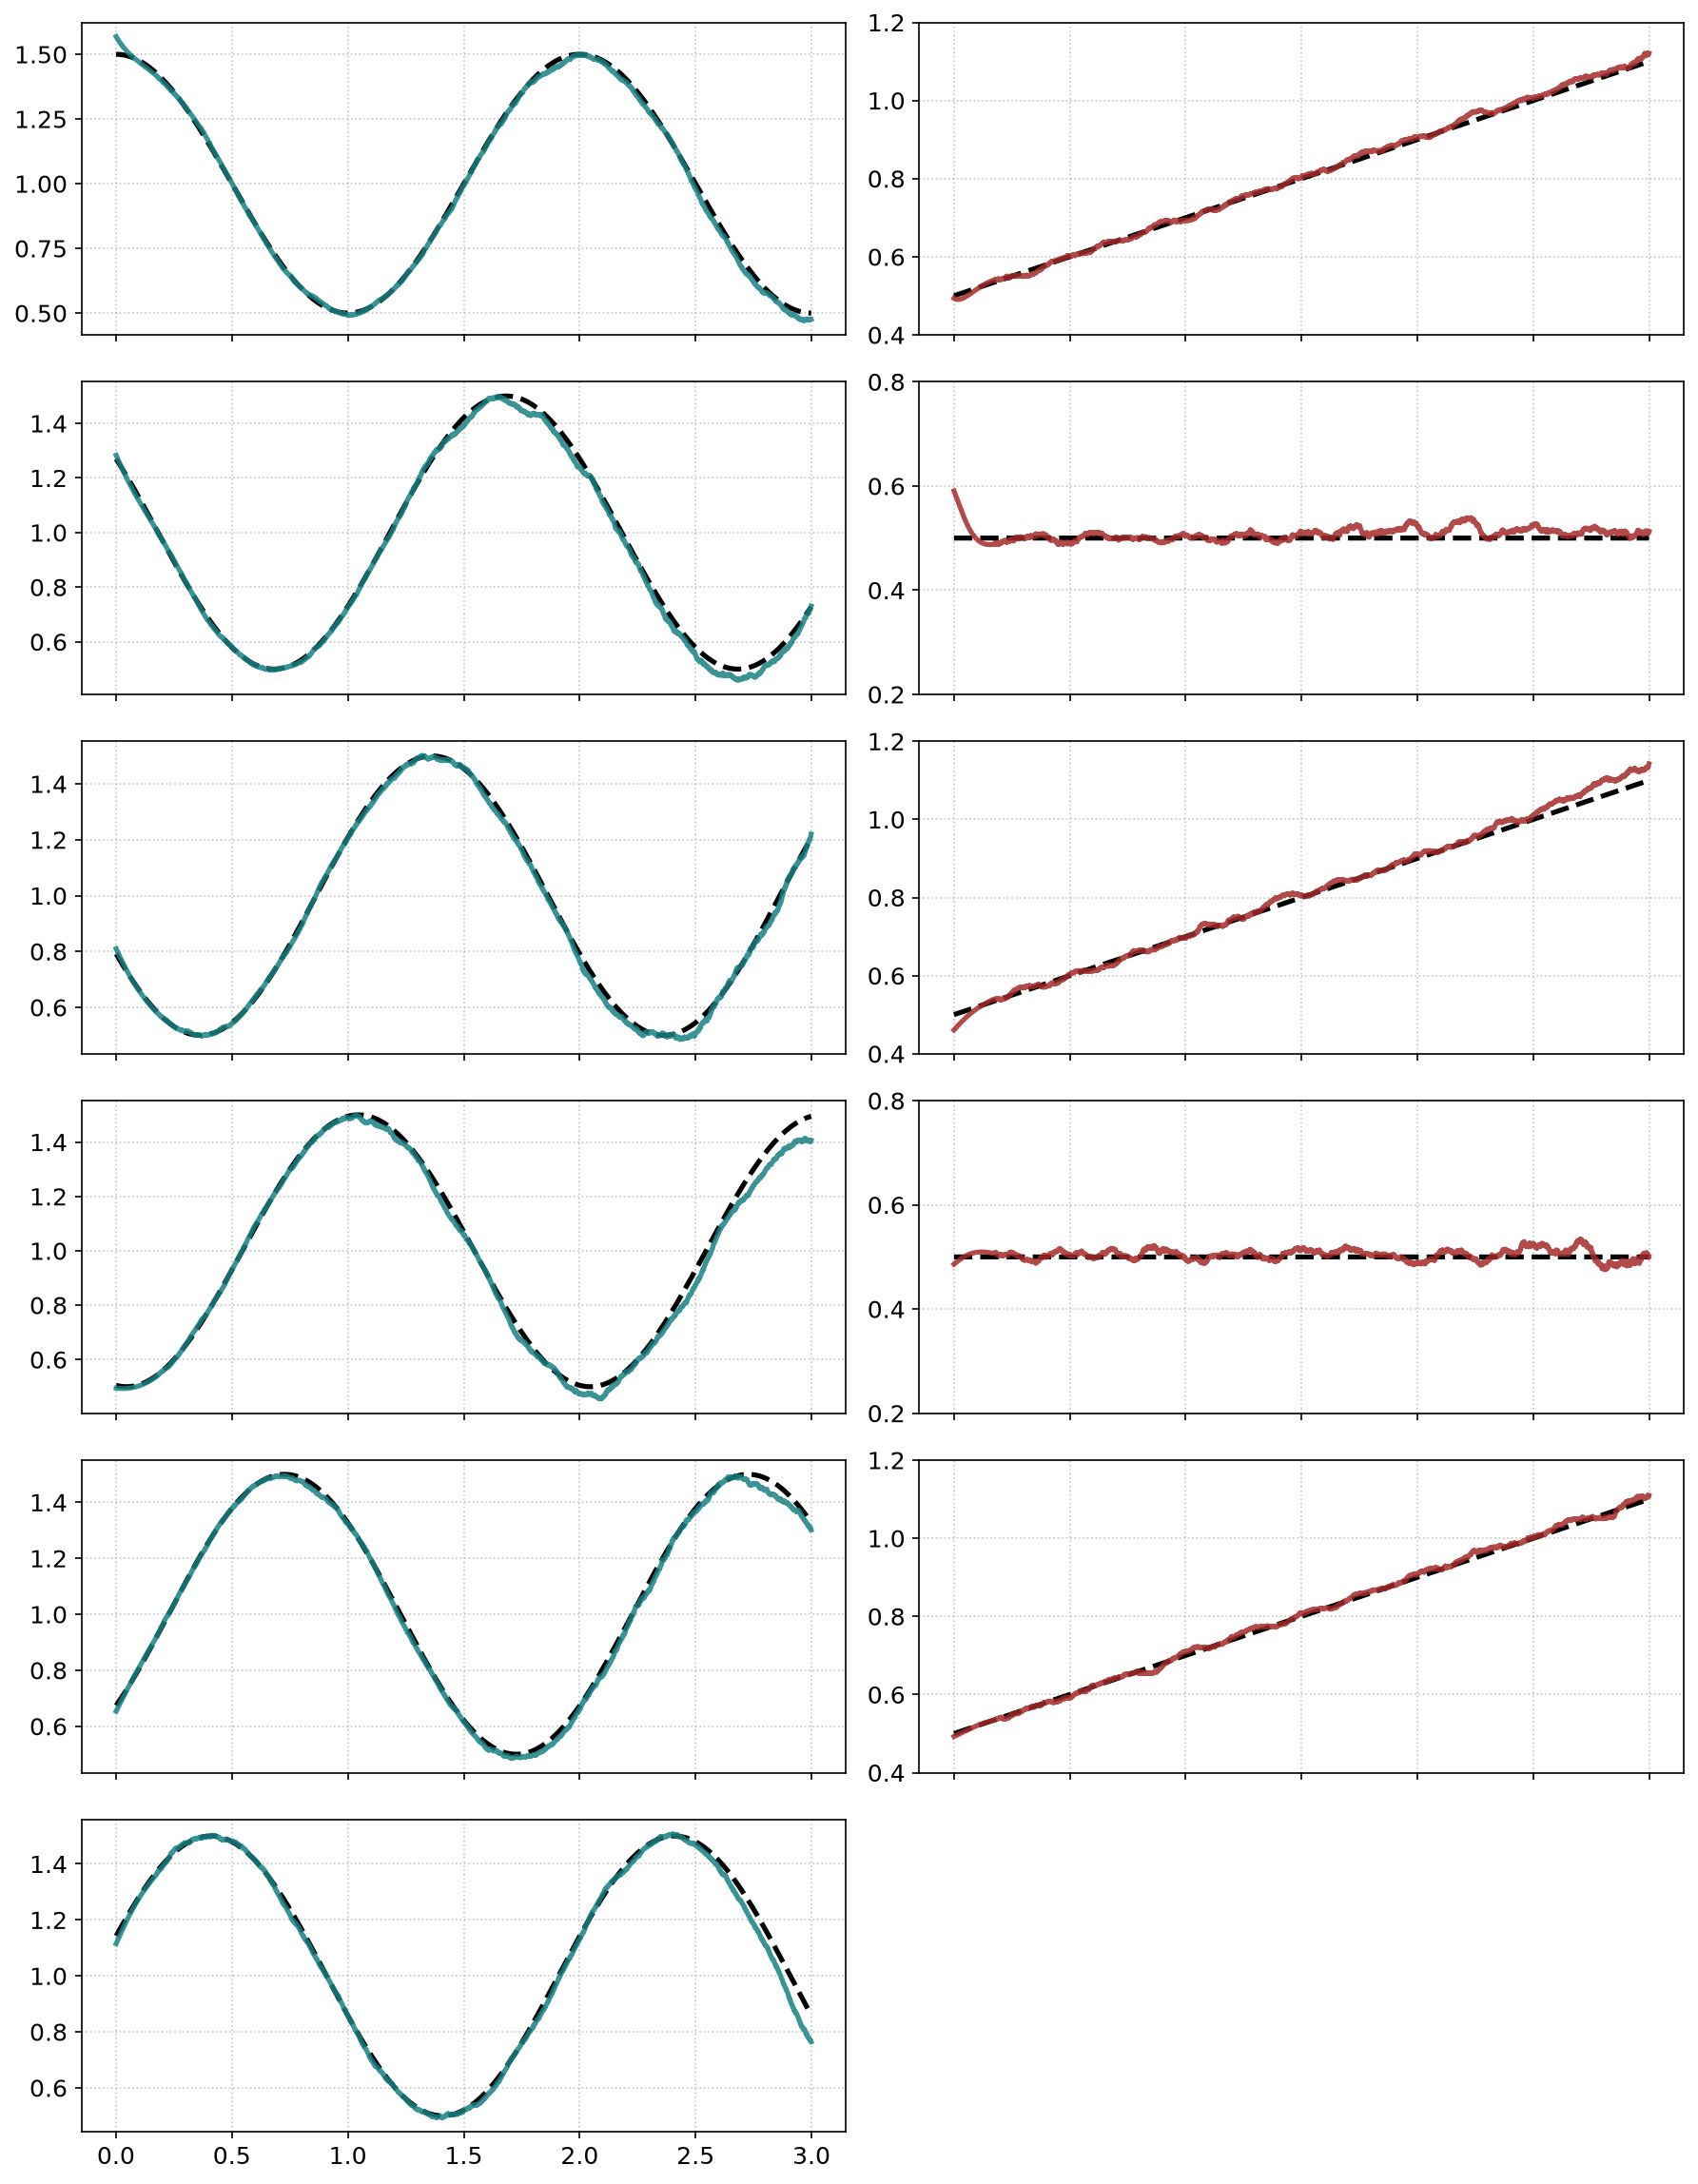

In [ ]:
color_local = '#178082'     # Teal/Blue for Local Fields
color_coupling = '#A52A2A'  # Brick/Red for Couplings
true_color = 'black'

plot_X = theta_X_over[:, 1:]
plot_YY = theta_YY_over[:, 1:]

actual_len = plot_X.shape[1]
t_plot_over = np.arange(1, actual_len + 1) * dt

n_qubits = 6

fig, axs = plt.subplots(n_qubits, 2, figsize=(12, 16), sharex=True, dpi=150)

# --- Plot Local Fields (Left Column) ---
for q in range(n_qubits):
    ax = axs[q, 0]
    ax.plot(t_plot_over, [true_Omega_X(q, t) for t in t_plot_over], 
            color=true_color, linestyle='--', lw=2.5)
    ax.plot(t_plot_over, plot_X[q, :], 
            color=color_local, alpha=0.85, lw=2.5)
    
    # ax.set_title(f'Field Qubit {q}')

# --- Plot Couplings (Right Column) ---
for c in range(n_qubits - 1):
    ax = axs[c, 1]
    ax.plot(t_plot_over, [true_J_YY(c, t) for t in t_plot_over], 
            color=true_color, linestyle='--', lw=2.5)
    ax.plot(t_plot_over, plot_YY[c, :], 
            color=color_coupling, alpha=0.85, lw=2.5)
    
    # ax.set_title(f'Coupling Qubits {c}-{c+1}')
    
    # Apply fair visual scaling depending on whether the coupling is dynamic or static
    # (Keeps a consistent 0.6 - 0.8 unit span so noise is visually comparable)
    if c % 2 == 0:
        ax.set_ylim(0.4, 1.2) # Fits the 0.5 -> 1.1 ramp
    else:
        ax.set_ylim(0.2, 0.8) # Fits the flat 0.5 line

# Hide the 12th (empty) subplot in the bottom right corner
axs[5, 1].axis('off')


for i in range(6):
    for j in range(2):
        # Skip formatting for the hidden axis
        if i == 5 and j == 1:
            continue
            
        axs[i, j].grid(True, linestyle=':', alpha=0.7)
        axs[i, j].tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.15)
plt.savefig("fullreconstruction_n6.pdf", bbox_inches="tight")
plt.show()